In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")

PyTorch : 2.12.0+cpu
Device  : cpu


In [2]:
########## Data Augmentation (nouveaute vs MLP) ################
# Le CNN peut beneficier de l'augmentation
# car il est invariant a de petites transformations

transform_train = transforms.Compose([
    transforms.RandomRotation(10),        # Rotation ±10°
    transforms.RandomAffine(0, shear=10), # Cisaillement
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='../data', train=True,
    download=True, transform=transform_train
)
test_dataset = torchvision.datasets.MNIST(
    root='../data', train=False,
    download=True, transform=transform_test
)

train_loader = DataLoader(
    train_dataset, batch_size=128,
    shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=128,
    shuffle=False, num_workers=0
)

print(f"Train : {len(train_dataset):,} images")
print(f"Test  : {len(test_dataset):,} images")
print(f"Shape : {next(iter(train_loader))[0].shape}")
#  (128, 1, 28, 28) = batch, canal, hauteur, largeur

Train : 60,000 images
Test  : 10,000 images
Shape : torch.Size([128, 1, 28, 28])


In [3]:
class CNN(nn.Module):
    """
    CNN identique au modele Keras :
    2 blocs Conv + MaxPool + classifieur Dense

    Differences syntaxiques PyTorch vs Keras :
      - nn.Conv2d(in_channels, out_channels, kernel_size)
      - nn.BatchNorm2d pour les couches conv (vs BatchNormalization)
      - nn.BatchNorm1d pour les couches denses
    """
    def __init__(self):
        super().__init__()

        ###### BLOC 1 : 32 filtres ######
        self.bloc1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 → 14x14
            nn.Dropout2d(0.25)
        )

        ###### BLOC 2 : 64 filtres #######
        self.bloc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 14x14 → 7x7
            nn.Dropout2d(0.25)
        )

        ###### CLASSIFIEUR ######
        self.classifier = nn.Sequential(
            nn.Flatten(),           # 7x7x64 = 3136
            nn.Linear(3136, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)    # 10 chiffres
        )

    def forward(self, x):
        x = self.bloc1(x)
        x = self.bloc2(x)
        x = self.classifier(x)
        return x


# Instancier et verifier
model_cnn_pt = CNN().to(device)

total_params = sum(p.numel() for p in model_cnn_pt.parameters())
print(f"\nParametres   : {total_params:,}")
print(f"  Keras CNN  : 469,098")
print(f"  PyTorch CNN: {total_params:,}")


Parametres   : 468,458
  Keras CNN  : 469,098
  PyTorch CNN: 468,458


In [4]:
optimizer  = optim.Adam(model_cnn_pt.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss()
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5,
    patience=5)

N_EPOCHS   = 50
best_acc   = 0.0
patience   = 10
no_improve = 0
history    = {'train_loss': [], 'val_acc': []}

print("Debut entrainement CNN PyTorch...")
print("="*50)

for epoch in range(1, N_EPOCHS+1):

    ################################ TRAIN ########################################
    model_cnn_pt.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn_pt(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    ############################## VALIDATION #######################################
    model_cnn_pt.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(model_cnn_pt(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc = correct / total
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Loss: {train_loss:.4f} | "
              f"Acc: {val_acc*100:.2f}%")

    # Early Stopping
    if val_acc > best_acc:
        best_acc   = val_acc
        no_improve = 0
        torch.save(model_cnn_pt.state_dict(),
                   '../models/cnn_pytorch_mnist.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly Stopping a l'epoch {epoch}")
            break

print(f"\n Entrainement termine !")
print(f"   Meilleure accuracy : {best_acc*100:.2f}%")

Debut entrainement CNN PyTorch...
Epoch   1/50 | Loss: 0.2449 | Acc: 98.93%
Epoch   5/50 | Loss: 0.0577 | Acc: 99.43%
Epoch  10/50 | Loss: 0.0386 | Acc: 99.61%
Epoch  15/50 | Loss: 0.0341 | Acc: 99.56%
Epoch  20/50 | Loss: 0.0240 | Acc: 99.64%
Epoch  25/50 | Loss: 0.0195 | Acc: 99.66%

Early Stopping a l'epoch 28

 Entrainement termine !
   Meilleure accuracy : 99.72%


COMPARAISON COMPLETE — MLP vs CNN
  Modele               | Accuracy   | Params      
  ---------------------+------------+-------------
  MLP Keras            | 98.52%     | 571,018     
  MLP PyTorch          | 98.59%     | 569,226     
  CNN Keras            | 99.61%     | 469,098     
  CNN PyTorch          | 99.72%      | 468,458     



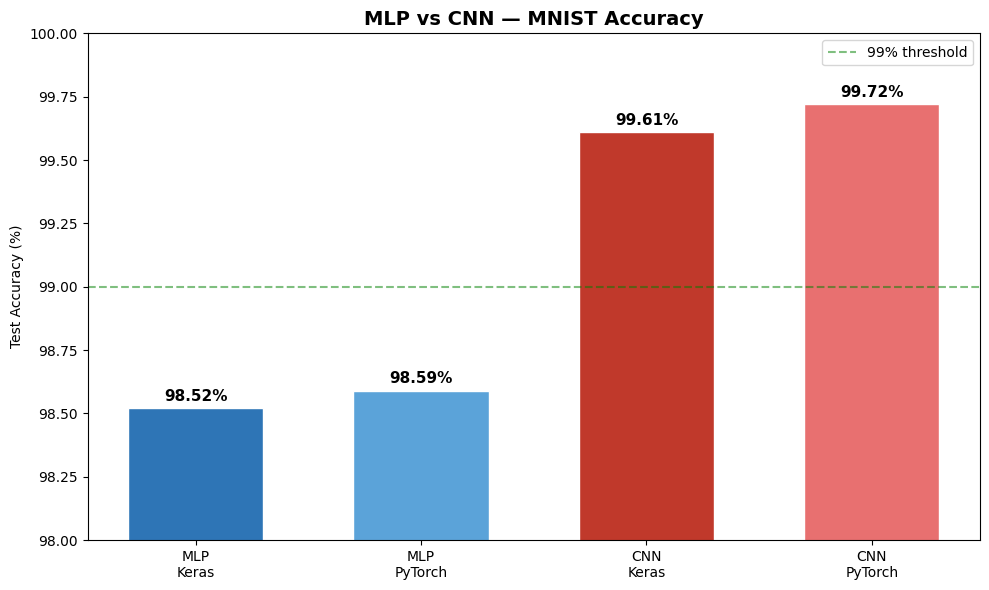


Conclusion :
  CNN > MLP de 1.20% avec 102,560 params de moins


In [5]:
# Charger le meilleur modele
model_cnn_pt.load_state_dict(
    torch.load('../models/cnn_pytorch_mnist.pt',
               map_location=device)
)
model_cnn_pt.eval()

# Collecter predictions
all_preds  = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, preds = torch.max(model_cnn_pt(images), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
cnn_pt_acc = (all_preds == all_labels).mean()

# Tableau de comparaison final
print("="*58)
print("COMPARAISON COMPLETE — MLP vs CNN")
print("="*58)
print(f"  {'Modele':20s} | {'Accuracy':10s} | {'Params':12s}")
print(f"  {'-'*20}-+-{'-'*10}-+-{'-'*12}")
print(f"  {'MLP Keras':20s} | {'98.52%':10s} | {'571,018':12s}")
print(f"  {'MLP PyTorch':20s} | {'98.59%':10s} | {'569,226':12s}")
print(f"  {'CNN Keras':20s} | {'99.61%':10s} | {'469,098':12s}")
print(f"  {'CNN PyTorch':20s} | {cnn_pt_acc*100:.2f}%{'':5s} | "
      f"{total_params:,}{'':5s}")
print()

# Graphique comparaison
fig, ax = plt.subplots(figsize=(10, 6))
models  = ['MLP\nKeras', 'MLP\nPyTorch', 'CNN\nKeras', 'CNN\nPyTorch']
accs    = [98.52, 98.59, 99.61, cnn_pt_acc*100]
colors  = ['#2E75B6', '#5BA3D9', '#C0392B', '#E87070']

bars = ax.bar(models, accs, color=colors,
              edgecolor='white', width=0.6)
ax.set_ylim(98.0, 100.0)
ax.set_title("MLP vs CNN — MNIST Accuracy",
             fontsize=14, fontweight='bold')
ax.set_ylabel("Test Accuracy (%)")
ax.axhline(y=99.0, color='green', linestyle='--',
           alpha=0.5, label='99% threshold')
ax.legend()

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'{acc:.2f}%', ha='center',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConclusion :")
print(f"  CNN > MLP de {cnn_pt_acc*100 - 98.52:.2f}% "
      f"avec {(571018-total_params):,} params de moins")